In [1]:
import os
import json
import subprocess

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def extract_ca_bfactors(pdb_file, chain_id):
    """
    Extract the B-factors of the alpha carbons (CA) from a given chain in a PDB file.
    
    Parameters:
        - pdb_file (str): Path to the PDB file
        - chain_id (char): PDB chain ID
    Returns:
        - bfactors (dict): Dictionary containing the residue numbers and b-factors of the associated CA structures
    """
    
    bfactors = {}

    with open(pdb_file, "r") as f:
        for line in f:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                if line[21].strip() != chain_id:
                    continue

                res_id = int(line[22:26].strip())
                bfac = float(line[60:66].strip())
                bfactors[res_id] = bfac
                
    return bfactors


In [3]:
def plot_ca_bfactors(path, pdb_file, chain_id, save_path, save="png"):
    """
    Extracts the B-factors of the alpha carbons (CA) from a protein chain in a PDB file and plots the corresponding curve.
    
    Parameters :
        - path (str): Path to the PDB file
        - pdb_file (str): Name of the PDB file
        - chain_id (char): PDB chain ID
        - save_path (str): Path to save the plots
        - save (str): File plot format (PDF or PNG)
    """

    pdb_path = f"{path}/{pdb_file}"
    res = []
    bfac = []
    bfactors = extract_ca_bfactors(pdb_path, chain_id)
    
    for i in bfactors.keys():
        res.append(float(i))
        
    for j in bfactors.values():
        bfac.append(float(j))

    save_path = f"{save_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    # Plot
    plt.figure(figsize=(10, 4))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.plot(res, bfac)
    plt.title(f"CA B-factor in {pdb_file} (chain {chain_id})", fontsize=14)
    plt.xlabel("Residues", fontsize=12)
    plt.ylabel("B-factor", fontsize=12)
    plt.ylim(0, 130)
    plt.yticks(np.linspace(0, 125, 6))
    plt.grid(True)

    if save == "png":
        plt.savefig(f"{save_path}ca_bfactors_chain{chain_id}.png", dpi=300)
    elif save == "pdf":
        plt.savefig(f"{save_path}ca_bfactors_chain{chain_id}.pdf", dpi=300)
    else:
        print("")
    
    plt.show()
    print(f"Graph saved in {save_path}ca_bfactors_chain{chain_id}.{save}")


In [4]:
def plot_few_bfactors(path, pdb_file, chain_1, chain_2, save_path, save="png"):
    """
    Extract the B-factors of the alpha carbons (CA) from two protein chains in PDB files and plot the two curves on the same graph.
    
    Parameters:
        - path (str): Path to the PDB file
        - pdb_file (str): Name of the PDB file
        - chain_1/2 (char): PDB chains ID
        - save_path (str): Path to save the plots
        - save (str): File plot format (PDF or PNG)
    """
    
    pdb_path = f"{path}/{pdb_file}"
    
    all1 = extract_ca_bfactors(pdb_path, chain_1)
    all2 = extract_ca_bfactors(pdb_path, chain_2)
    
    res1 = all1.keys()
    res2 = all2.keys()
    
    bf1 = all1.values()
    bf2 = all2.values()

    save_path = f"{save_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    # Plot
    plt.figure(figsize=(10, 4))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.plot(res1, bf1, label=f"chain {chain_1}")
    plt.plot(res2, bf2, label=f"chain {chain_2}")
    plt.title(f"CA B-factor for {pdb_file} chain {chain_1} and chain {chain_2}", fontsize=14)
    plt.xlabel("Residues", fontsize=12)
    plt.ylabel("B-factor", fontsize=12)
    plt.ylim(0, 130)
    plt.yticks(np.linspace(0, 125, 6))
    plt.grid(True)
    plt.legend()

    if save == "png":
        plt.savefig(f"{save_path}ca_bfactors_chains{chain_1}{chain_2}.png", dpi=300)
    elif save == "pdf":
        plt.savefig(f"{save_path}ca_bfactors_chains{chain_1}{chain_2}.pdf", dpi=300)
    else:
        print("")

    plt.show()
    print(f"Graph saved in {save_path}ca_bfactors_chains{chain_1}{chain_2}.{save}")


In [5]:
def plot_mean_bfactors(path, pdb_file, chain_1, chain_2, save_path, save="png"):
    """
    Plot an average profile of the B-factors for alpha carbons (CA) between two chains, while retaining those present in only one of the chains.
    
    Parameters:
        - path (str): Path to the PDB file
        - pdb_file (str): Name to the PDB file
        - chain_1/2 (char): PDB chains ID
        - save_path (str): Path to save the plots
        - save (str): File plot format (PDF or PNG)
    """

    pdb_path = f"{path}/{pdb_file}"
    
    bf1 = extract_ca_bfactors(pdb_path, chain_1)
    bf2 = extract_ca_bfactors(pdb_path, chain_2)

    # Merged of all residues present in either chain
    all_residues = sorted(set(bf1.keys()) | set(bf2.keys()))

    mean_bfactors = []
    for r in all_residues:
        if r in bf1 and r in bf2:
            mean_bfactors.append((bf1[r] + bf2[r]) / 2)
        elif r in bf1:
            mean_bfactors.append(bf1[r])
        else:
            mean_bfactors.append(bf2[r])

    save_path = f"{save_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.plot(all_residues, mean_bfactors)
    plt.title(f"Mean CA B-factor: {pdb_file} chain {chain_1} + chain {chain_2}", fontsize=14)
    plt.xlabel("Residues", fontsize=12)
    plt.ylabel("B-factor (CA)", fontsize=12)
    plt.ylim(0, 130)
    plt.yticks(np.linspace(0, 125, 6))
    plt.grid(True)

    if save == "png":
        plt.savefig(f"{save_path}mean_ca_bfactors{chain_1}{chain_2}.png", dpi=300)
    elif save == "pdf":
        plt.savefig(f"{save_path}mean_ca_bfactors{chain_1}{chain_2}.pdf", dpi=300)
    else:
        print("")

    plt.show()
    print(f"Graph saved in {save_path}mean_ca_bfactors{chain_1}{chain_2}.{save}")


In [6]:
def find_files_AF3(directory, number_models=5):
    """
    Generates a JSON file path list for a specified number of models in a specified base path.
    
    Parameters:
        - directory (str): The default directory where the JSON files for the models are stored
        - number_models (int): number of structural models
    Returns:
        - json_files (list): List of full paths to the JSON files
    """

    # Run "select_plddt_CA.sh" must be in the right directory
    bash_directory = directory.replace("C:/", "/mnt/c/")
    subprocess.run(["bash", "../selec_plDDT_CA.sh", f"{bash_directory}"], capture_output=True, text=True)

    name = os.path.splitext(os.path.basename(directory))[0]
    json_files = [f"{directory}/{name}_model_{model}_result.json" for model in range(number_models)]
    return json_files


In [7]:
def merge_json_AF3(directory, input_files, key, output_file="merged_AF3.json"):
    """
    Merges multiple JSON files into a single file by calculating the average of the key values.
    
    Parameters:
         - directory (str): Path to the directory containing the JSON files
         - input_files (list): List of JSON files to merge
         - key (str): key to average
    Returns:
        - output_file (dict): Dictionary containing the averages (e.g., merged_AF3.json")
    """

    # Opening Files
    all_plddt = []
    for file in input_files:
        with open(file, "r") as f:
            data = json.load(f)      
        all_plddt.append(data[key])
    
    # Conversion to an array and calculation of the average by residue
    all_plddt = np.array(all_plddt)
    mean_plddt = np.mean(all_plddt, axis=0)
    
    # Use a reference file for the other indexes
    with open(input_files[0], "r") as f:
        ref_data = json.load(f)

    # Creating the dictionary
    output = {
        "nbr_res": ref_data["nbr_res"],
        "number_atoms": ref_data["number_atoms"],
        f"{key}_mean": mean_plddt.tolist()
    }
    
    # Output file path
    output_path = os.path.join(directory, output_file)

    # Saving data to a file
    with open(output_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"{key} averaged and saved in: {directory}/{output_file}")


In [8]:
def plot_merged_json(path, name, begin, end, save_path, save="png", json_name="merged_AF3.json", key_to_plot="plDDT_mean"):
    """
    Plot a graph of the values for a specific key from a merged JSON file.
    
    Parameters:
        - path (str): Path to the merged JSON file
        - name (str): Name of the protein to plot
        - begin (int): First residue to plot
        - end (int): Last residue to plot
        - save_path (str): Path to save the plots
        - save (str): File plot format (PDF or PNG)
        - json_name (str): name of merged JSON file (e.g., merged_AF3.json")
        - key_to_plot (str): key whose values must be plot (e.g., "plDDT_mean")
    """

    json_file = f"{path}/{json_name}"
    print(json_file)
    with open(json_file, "r") as f:
        data = json.load(f)
    
    if key_to_plot not in data:
        print(f"The key '{key_to_plot}' doesn't exist in the JSON file.")
        return
    
    values = data[key_to_plot]
    residues = data["nbr_res"]
    
    save_path = f"{save_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.plot(residues[begin:end], values[begin:end])  # Adjust the indices according to the region of interest
    plt.title(f"plDDT scores for {name} with AF3", fontsize=14)
    plt.xlabel("Residues", fontsize=12)
    plt.ylabel(key_to_plot, fontsize=12)
    plt.yticks(np.linspace(0, 100, 5))
    plt.ylim(0, 105)
    plt.grid(True)

    if save == "png":
        plt.savefig(f"{save_path}{name}_{key_to_plot}_plot.png", dpi=300)
    elif save == "pdf":
        plt.savefig(f"{save_path}{name}_{key_to_plot}_plot.pdf", dpi=300)
    else:
        print("")

    plt.show()
    print(f"Graph saved in {save_path}{name}_{key_to_plot}_plot.{save}")
    

In [9]:
def plot_merged_bfact_plddt(path, cristal_path, cristal_name, begin, end, chain_1, chain_2, name, save_path, save="png", json_name="merged_AF3.json", key_to_plot="plDDT_mean"):
    """
    Plot a graph showing the average of the two b-factors and the average of the plDDT values obtained from the models generated by AF3.
    
    Parameters:
        - path (str): Path to the models files for the plDDT values
        - cristal_path (str): Path to the cristal files for the bfactors values
        - cristal_name (str): Name of PDB files for the bfactors values
        - begin (int): First residue to plot
        - end (int): Last residue to plot
        - chain_1/2 (char): Chain ID to plot
        - name (str): Name of the protein to plot
        - save_path (str): Path to save the plots
        - save (str): File plot format (PDF or PNG)
        - json_name (str): name of merged JSON file (e.g., merged_AF3.json")
        - key_to_plot (str): key whose values must be plot (e.g., "plDDT_mean")
    """

    json_file = f"{path}/{json_name}"
    with open(json_file, "r") as f:
        data_plddt = json.load(f)
    
    values_pred = data_plddt["plDDT_mean"]
    residues_pred = data_plddt["nbr_res"]

    pdb_path = f"{cristal_path}/{cristal_name}"
    
    bf1 = extract_ca_bfactors(pdb_path, chain_1)
    bf2 = extract_ca_bfactors(pdb_path, chain_2)
    all_residues = sorted(set(bf1.keys()) | set(bf2.keys()))

    mean_bfactors = []
    for r in all_residues:
        if r in bf1 and r in bf2:
            mean_bfactors.append((bf1[r] + bf2[r]) / 2)
        elif r in bf1:
            mean_bfactors.append(bf1[r])
        else:
            mean_bfactors.append(bf2[r])

    # Save the plots
    save_path = f"{save_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.plot(residues_pred[begin:end], values_pred[begin:end], label="plDDT")
    plt.plot(all_residues, mean_bfactors, label="bfactor")
    plt.title(f"plDDT/bfactor scores for {name}", fontsize=14)
    plt.xlabel("Residues", fontsize=12)
    plt.ylabel("plDDT/bfactor", fontsize=12)
    plt.legend()
    plt.grid(True)

    if save == "png":
        plt.savefig(f"{save_path}{name}_plDDT_bfactor_plot.png", dpi=300)
    elif save == "pdf":
        plt.savefig(f"{save_path}{name}_plDDT_bfactor_plot.pdf", dpi=300)
    else:
        print("")
        
    plt.show()
    print(f"Graph saved in {save_path}{name}_plDDT_bfactor_plot.save")
    

In [10]:
# Generating bfactors graphs

In [11]:
save_path = "../example_data/MeCP2_TBL1R"
cristal_path = "../example_data/MeCP2_TBL1R/Xp"
cristal_name = "5naf.pdb"

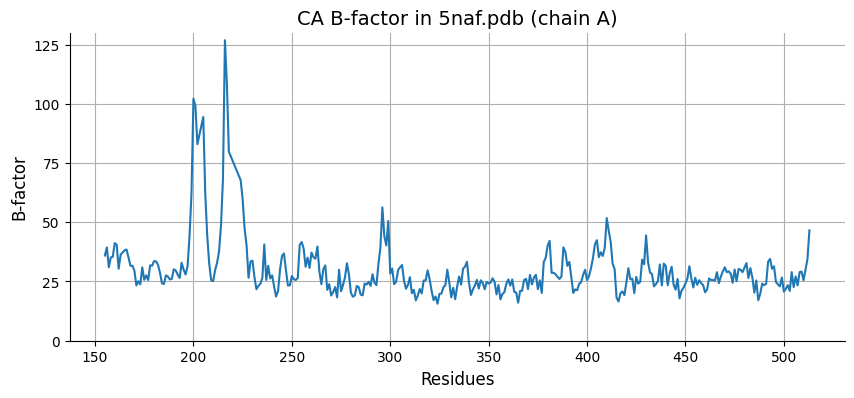

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainA.png


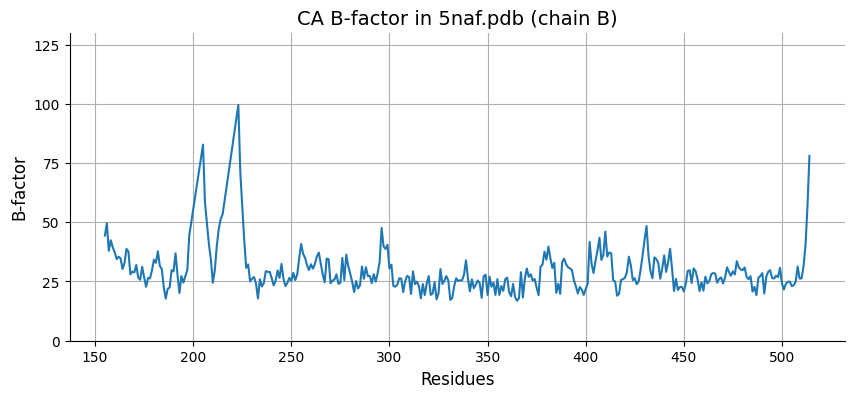

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainB.png


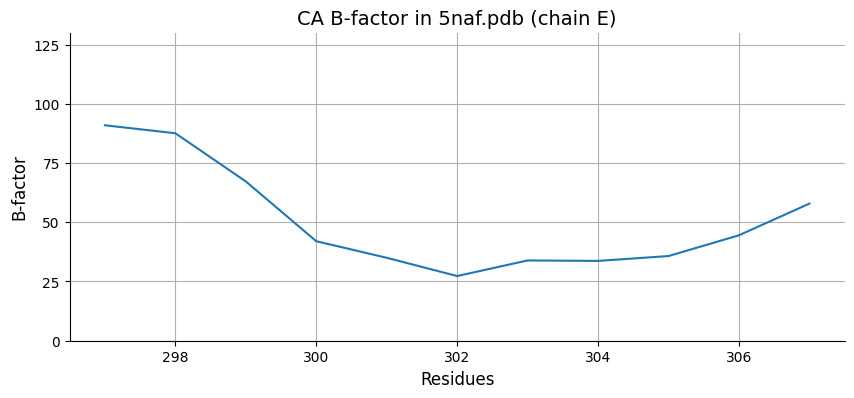

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainE.png


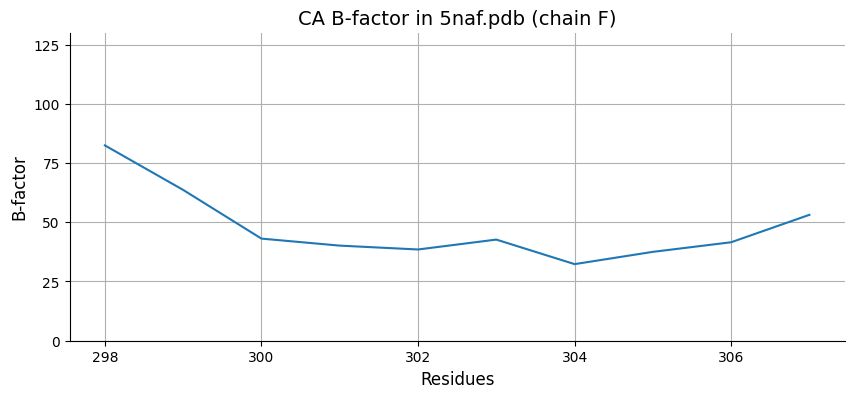

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainF.png


In [12]:
plot_ca_bfactors(cristal_path, cristal_name, "A", save_path)
plot_ca_bfactors(cristal_path, cristal_name, "B", save_path)
plot_ca_bfactors(cristal_path, cristal_name, "E", save_path)
plot_ca_bfactors(cristal_path, cristal_name, "F", save_path)

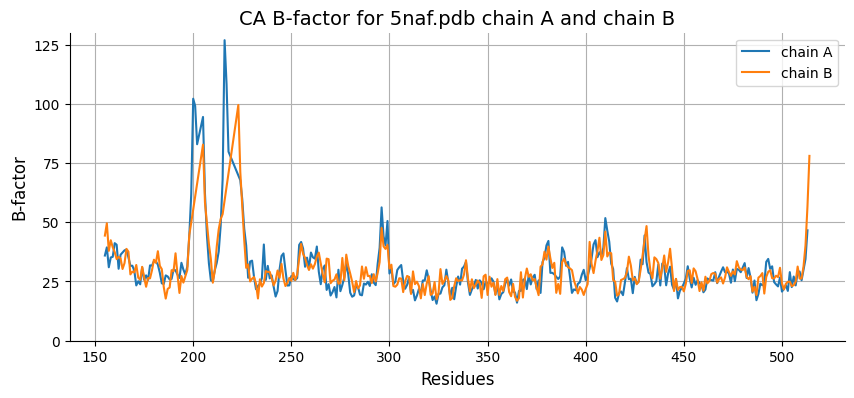

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainsAB.png


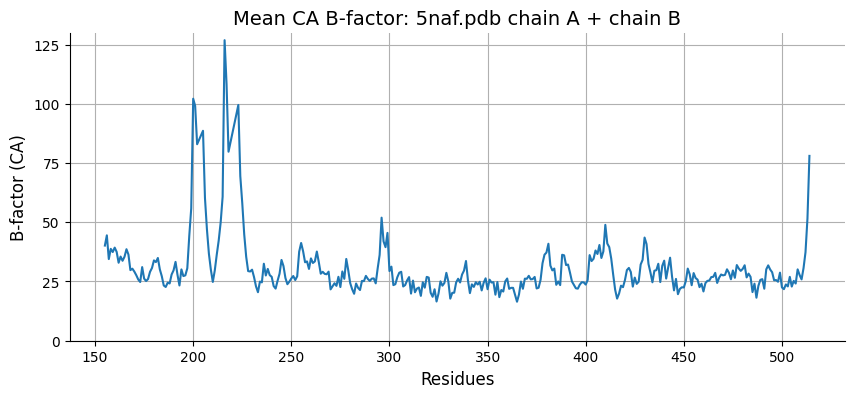

Graph saved in ../example_data/MeCP2_TBL1R/Plots/mean_ca_bfactorsAB.png


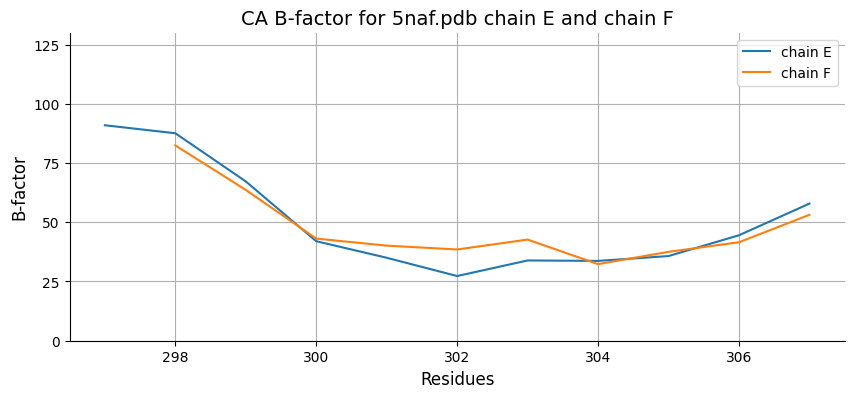

Graph saved in ../example_data/MeCP2_TBL1R/Plots/ca_bfactors_chainsEF.png


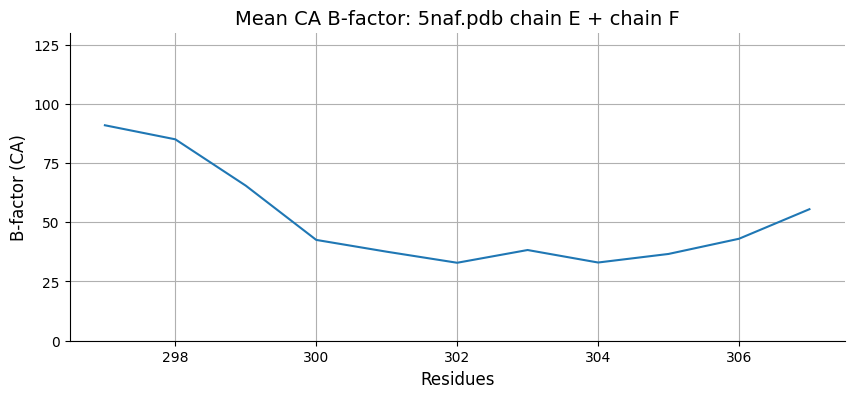

Graph saved in ../example_data/MeCP2_TBL1R/Plots/mean_ca_bfactorsEF.png


In [13]:
plot_few_bfactors(cristal_path, cristal_name, "A", "B", save_path)
plot_mean_bfactors(cristal_path, cristal_name, "A", "B", save_path)
plot_few_bfactors(cristal_path, cristal_name, "E", "F", save_path)
plot_mean_bfactors(cristal_path, cristal_name, "E", "F", save_path)

In [14]:
# Generating plDDT graphs

In [15]:
pred_path = "../example_data/MeCP2_TBL1R/fold_mmecp2_mtbl1r"
json_files_AF3 = find_files_AF3(pred_path)
merge_json = merge_json_AF3(pred_path, json_files_AF3, "plDDT")

plDDT averaged and saved in: ../example_data/MeCP2_TBL1R/fold_mmecp2_mtbl1r/merged_AF3.json


../example_data/MeCP2_TBL1R/fold_mmecp2_mtbl1r/merged_AF3.json


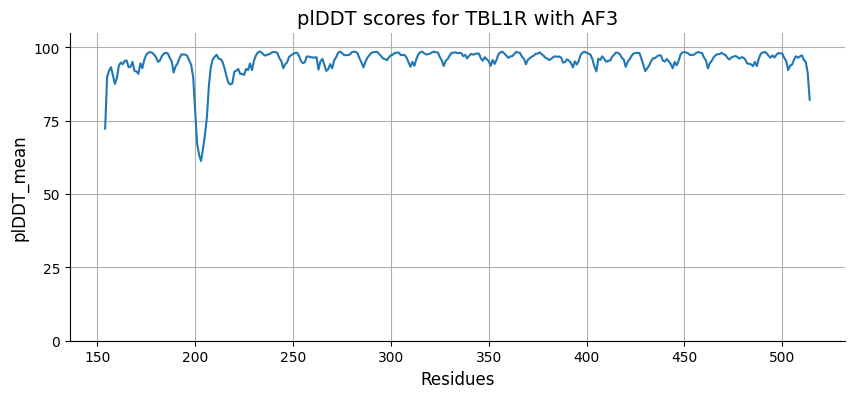

Graph saved in ../example_data/MeCP2_TBL1R/Plots/TBL1R_plDDT_mean_plot.png
../example_data/MeCP2_TBL1R/fold_mmecp2_mtbl1r/merged_AF3.json


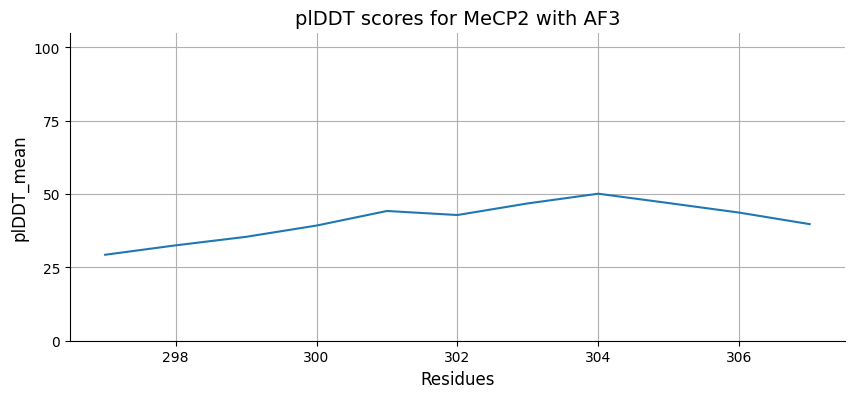

Graph saved in ../example_data/MeCP2_TBL1R/Plots/MeCP2_plDDT_mean_plot.png


In [16]:
plot_merged_json(pred_path, "TBL1R", 637, 1000, save_path)
plot_merged_json(pred_path, "MeCP2", 296, 307, save_path)

In [17]:
# Comparison of plDDT and bfactors score

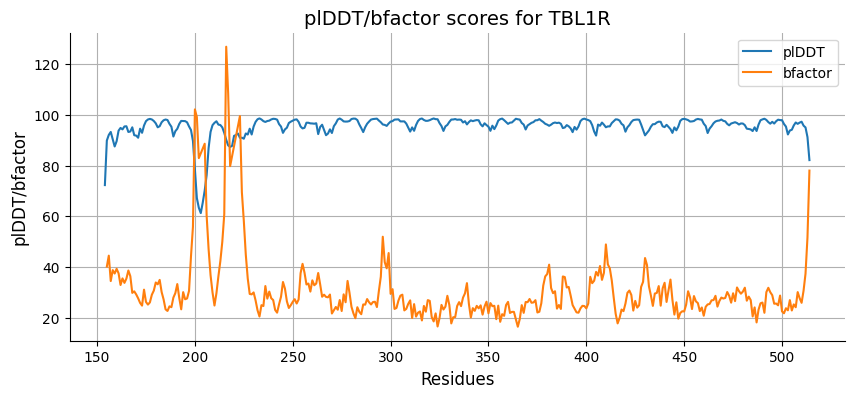

Graph saved in ../example_data/MeCP2_TBL1R/Plots/TBL1R_plDDT_bfactor_plot.save


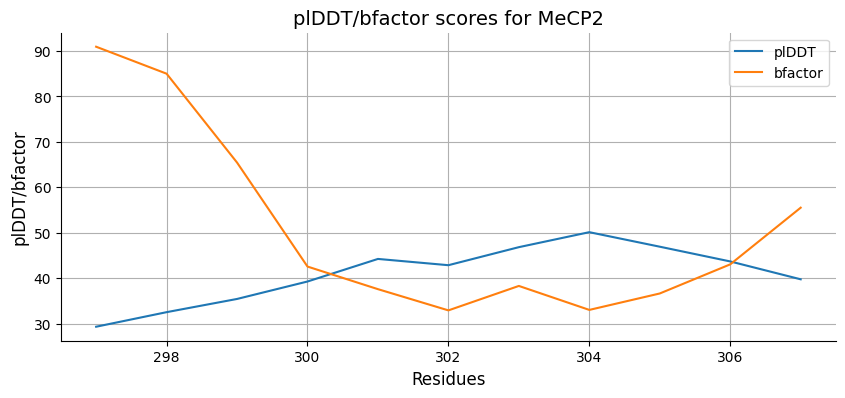

Graph saved in ../example_data/MeCP2_TBL1R/Plots/MeCP2_plDDT_bfactor_plot.save


In [19]:
plot_merged_bfact_plddt(pred_path, cristal_path, cristal_name, 637, 1000, "A", "B", "TBL1R", save_path)
plot_merged_bfact_plddt(pred_path, cristal_path, cristal_name, 296, 307, "E", "F", "MeCP2", save_path)